This part is to split the cleaned data as requirement which is 80/20

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import os

#
#  Find repo root
# 
NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start_path: Path):
    cur = start_path
    for _ in range(10):
        if (cur / ".git").exists() or (cur / "data").exists():
            return cur
        cur = cur.parent
    return start_path

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

# 
# Set up Path
#
DATA_DIR = REPO_ROOT / "data"
PROC_DIR = DATA_DIR / "processed"
PLOT_DIR = REPO_ROOT / "plots"
in_path = PROC_DIR / "final_processed_data.parquet"

train_out_path = PROC_DIR / "train_subject_split.parquet"
test_out_path  = PROC_DIR / "test_subject_split.parquet"

print("Repo root:", REPO_ROOT)
print("Input parquet:", in_path)
print("Train output :", train_out_path)
print("Test output  :", test_out_path)

# 
# Read Data
# 
dataFrame = pd.read_parquet(in_path)
print(f"rows: {len(dataFrame)}")

Group_col = "subject"
Label_col = "behavior"

print(f"subjects: {dataFrame[Group_col].unique()}")

#
# Group-aware train / test split
# 
test_data_col = dataFrame.drop(columns=[Label_col])
test_behavior_col = dataFrame[Label_col]
groups = dataFrame[Group_col]

#
# n_splits=1：splists only once
#
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(test_data_col, test_behavior_col, groups=groups)
)

train_dataFrame = dataFrame.iloc[train_idx].reset_index(drop=True)
test_dataFrame  = dataFrame.iloc[test_idx].reset_index(drop=True)

print(f"Train groups (Subjects): {train_dataFrame[Group_col].unique()}")
print(f"Test groups (Subjects):  {test_dataFrame[Group_col].unique()}")

# 
# Saved output to data/processed
# 
train_dataFrame.to_parquet(train_out_path, index=False)
test_dataFrame.to_parquet(test_out_path, index=False)

print("Saved train split to:", train_out_path)
print("Saved test split  to:", test_out_path)


Repo root: E:\A1_last_version
Input parquet: E:\A1_last_version\data\processed\final_processed_data.parquet
Train output : E:\A1_last_version\data\processed\train_subject_split.parquet
Test output  : E:\A1_last_version\data\processed\test_subject_split.parquet
rows: 536115
subjects: ['SUBJ_059520' 'SUBJ_020948' 'SUBJ_040282' 'SUBJ_052342' 'SUBJ_032165'
 'SUBJ_024086' 'SUBJ_040733' 'SUBJ_063346' 'SUBJ_055211' 'SUBJ_001430'
 'SUBJ_012088' 'SUBJ_040310' 'SUBJ_032233' 'SUBJ_059330' 'SUBJ_013623'
 'SUBJ_032585' 'SUBJ_063464' 'SUBJ_038023' 'SUBJ_024137' 'SUBJ_030676'
 'SUBJ_047636' 'SUBJ_053173' 'SUBJ_057917' 'SUBJ_040724' 'SUBJ_049223'
 'SUBJ_019262' 'SUBJ_053906' 'SUBJ_027682' 'SUBJ_058786' 'SUBJ_000206'
 'SUBJ_032761' 'SUBJ_017170' 'SUBJ_041243' 'SUBJ_019663' 'SUBJ_061552'
 'SUBJ_032704' 'SUBJ_041770' 'SUBJ_040106' 'SUBJ_039234' 'SUBJ_050642'
 'SUBJ_021670' 'SUBJ_056936' 'SUBJ_042779' 'SUBJ_034574' 'SUBJ_008304'
 'SUBJ_064387' 'SUBJ_054811' 'SUBJ_045235' 'SUBJ_017807' 'SUBJ_034631'
 'SUBJ

This step is to normalize the splited data

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# 
#  find out repo root
# 
NOTEBOOK_DIR = Path.cwd()

def find_repo_root(start_path: Path):
    cur = start_path
    for _ in range(10):
        if (cur / ".git").exists() or (cur / "data").exists():
            return cur
        cur = cur.parent
    return start_path

REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

# 
# set up route
# 
DATA_DIR = REPO_ROOT / "data"
PROC_DIR = DATA_DIR / "processed"

train_path = PROC_DIR / "train_subject_split.parquet"
test_path  = PROC_DIR / "test_subject_split.parquet"

train_out_path = PROC_DIR / "train_normalized.parquet"
test_out_path  = PROC_DIR / "test_normalized.parquet"

print("Repo root:", REPO_ROOT)
print("Train in :", train_path)
print("Test in  :", test_path)

# 
# Read Data
# 
train_data = pd.read_parquet(train_path)
test_data  = pd.read_parquet(test_path)


acc_cols = ['acc_x', 'acc_y', 'acc_z']
rot_cols = ['rot_w', 'rot_x', 'rot_y', 'rot_z']
thm_cols = ['thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5']

TOF_COLS = [c for c in train_data.columns if 'tof' in c]

cols_to_norm = acc_cols + rot_cols + thm_cols + TOF_COLS
print("Columns to normalize:")
print(cols_to_norm)

# 
# Normalization
# 
scaler = StandardScaler()
scaler.fit(train_data[cols_to_norm])

train_data[cols_to_norm] = scaler.transform(train_data[cols_to_norm])
test_data[cols_to_norm]  = scaler.transform(test_data[cols_to_norm])

# 
# save normalization data
# 
train_data.to_parquet(train_out_path, index=False)
test_data.to_parquet(test_out_path, index=False)

print("Saved normalized train to:", train_out_path)
print("Saved normalized test  to:", test_out_path)


Repo root: E:\A1_last_version
Train in : E:\A1_last_version\data\processed\train_subject_split.parquet
Test in  : E:\A1_last_version\data\processed\test_subject_split.parquet
Columns to normalize:
['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5', 'tof_1_v0', 'tof_1_v1', 'tof_1_v2', 'tof_1_v3', 'tof_1_v4', 'tof_1_v5', 'tof_1_v6', 'tof_1_v7', 'tof_1_v8', 'tof_1_v9', 'tof_1_v10', 'tof_1_v11', 'tof_1_v12', 'tof_1_v13', 'tof_1_v14', 'tof_1_v15', 'tof_1_v16', 'tof_1_v17', 'tof_1_v18', 'tof_1_v19', 'tof_1_v20', 'tof_1_v21', 'tof_1_v22', 'tof_1_v23', 'tof_1_v24', 'tof_1_v25', 'tof_1_v26', 'tof_1_v27', 'tof_1_v28', 'tof_1_v29', 'tof_1_v30', 'tof_1_v31', 'tof_1_v32', 'tof_1_v33', 'tof_1_v34', 'tof_1_v35', 'tof_1_v36', 'tof_1_v37', 'tof_1_v38', 'tof_1_v39', 'tof_1_v40', 'tof_1_v41', 'tof_1_v42', 'tof_1_v43', 'tof_1_v44', 'tof_1_v45', 'tof_1_v46', 'tof_1_v47', 'tof_1_v48', 'tof_1_v49', 'tof_1_v50', 'tof_1_v51', 'tof_1_v52', 'tof_1_v53', 't

This code is to check if the nomalization is correct or not

              row_id sequence_type sequence_id  sequence_counter      subject  \
0  SEQ_000013_000000        Target  SEQ_000013                 0  SUBJ_040282   
1  SEQ_000013_000001        Target  SEQ_000013                 1  SUBJ_040282   
2  SEQ_000013_000002        Target  SEQ_000013                 2  SUBJ_040282   
3  SEQ_000013_000003        Target  SEQ_000013                 3  SUBJ_040282   
4  SEQ_000013_000004        Target  SEQ_000013                 4  SUBJ_040282   

                  orientation                                   behavior  \
0  Lie on Side - Non Dominant  Relaxes and moves hand to target location   
1  Lie on Side - Non Dominant  Relaxes and moves hand to target location   
2  Lie on Side - Non Dominant  Relaxes and moves hand to target location   
3  Lie on Side - Non Dominant  Relaxes and moves hand to target location   
4  Lie on Side - Non Dominant  Relaxes and moves hand to target location   

        phase             gesture     acc_x  ...  tof_5_

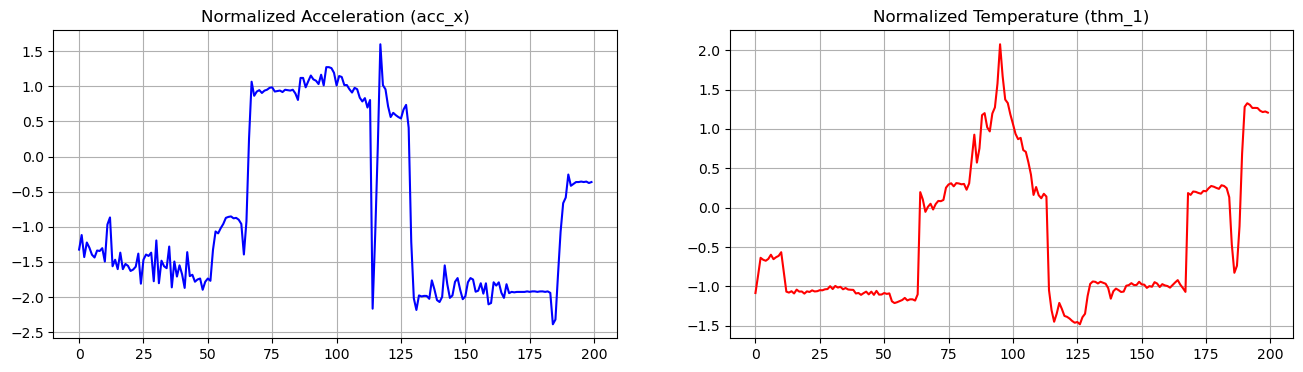

In [3]:
import matplotlib.pyplot as plt
import os
print(test_data.head())
print(test_data[['acc_x', 'thm_1']].describe())
plt.figure(figsize=(16, 4))
plt.subplot(1, 2, 1)
plt.plot(test_data['acc_x'].iloc[:200], label='acc_x (Normalized)', color='blue')
plt.title('Normalized Acceleration (acc_x)')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(test_data['thm_1'].iloc[:200], label='thm_1 (Normalized)', color='red')
plt.title('Normalized Temperature (thm_1)')
plt.grid(True)
save_path = os.path.join(PLOT_DIR, "Normaliaztion_accx_thm1.png")
plt.savefig(save_path, dpi=300)

plt.show()